# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal para clasificación de imágenes usando **Keras 3**.

En este ejercicio aplicarás **la misma receta** sobre un dataset diferente: **CIFAR-10 convertido a escala de grises**.

No necesitas diseñar un pipeline nuevo. La descarga, conversión a escala de grises y visualización están resueltas. Tu trabajo es completar únicamente las etapas de Keras que vimos en clase:

```text
Datos → Normalización → Modelo → Loss + Optimizer → fit() → evaluate() → Predicción
```

Las celdas marcadas con `# TODO` son las que debes completar.


---
## 0. Librerías


In [1]:
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


Keras version : 3.15.1
Backend       : tensorflow


---
# 1. Dataset: CIFAR-10

CIFAR-10 contiene 50,000 imágenes de entrenamiento y 10,000 de prueba. Las imágenes originales son de **32×32×3** y pertenecen a 10 categorías:

`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`.


In [2]:
# Esta parte está resuelta.
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.squeeze()
y_test = y_test.squeeze()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("X_train original:", X_train.shape)
print("X_test original :", X_test.shape)
print("y_train         :", y_train.shape)


X_train original: (50000, 32, 32, 3)
X_test original : (10000, 32, 32, 3)
y_train         : (50000,)


## 1.1 RGB → escala de grises

Usaremos la transformación:

$$Gray = 0.299R + 0.587G + 0.114B$$

Esta parte está resuelta porque el objetivo del ejercicio es practicar Keras.


In [3]:
X_train = (
    0.299 * X_train[..., 0] +
    0.587 * X_train[..., 1] +
    0.114 * X_train[..., 2]
)

X_test = (
    0.299 * X_test[..., 0] +
    0.587 * X_test[..., 1] +
    0.114 * X_test[..., 2]
)

print("X_train grayscale:", X_train.shape)
print("X_test grayscale :", X_test.shape)


X_train grayscale: (50000, 32, 32)
X_test grayscale : (10000, 32, 32)


### Pregunta 1

Después de convertir las imágenes a escala de grises, cada imagen tiene tamaño `32×32`.

¿Cuántos valores tendrá cada imagen después de aplicar `Flatten()`?

**Respuesta:** $32\times32=$ **1024 valores** por imagen.



## 1.2 Normalización

Los valores de los píxeles están entre 0 y 255. Completa el código para llevarlos al rango `[0,1]`.


In [4]:
# TODO 1 — Normalización
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

print(X_train.min(), X_train.max())


0.0 1.0


In [5]:
# Validación TODO 1
assert X_train.dtype == np.float32
assert X_test.dtype == np.float32
assert X_train.min() >= 0.0
assert X_train.max() <= 1.0
print("✓ Datos normalizados correctamente")


✓ Datos normalizados correctamente


## 1.3 Visualización

Esta parte está resuelta.


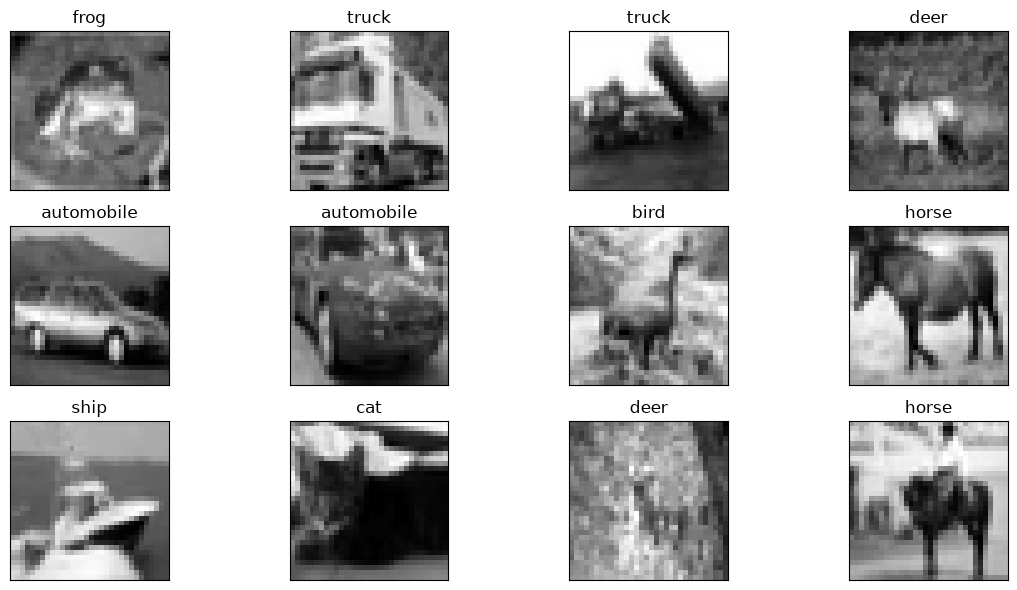

In [6]:
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Construiremos la misma arquitectura conceptual vista en clase:

```text
Imagen 32×32
   ↓
Flatten
   ↓
1024 valores
   ↓
Dense(128)
   ↓
ReLU
   ↓
Dense(10)
   ↓
Logits
```

> La última capa **no** debe tener Softmax. Trabajaremos con logits.


In [7]:
# TODO 2 — Completa la arquitectura
model = keras.Sequential([
    keras.Input(shape=(32, 32)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10)
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,490 (517.54 KB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Validación TODO 2
expected_params = (1024 * 128 + 128) + (128 * 10 + 10)
assert model.count_params() == expected_params
print(f"✓ Arquitectura correcta: {model.count_params():,} parámetros")


✓ Arquitectura correcta: 132,490 parámetros


### Preguntas

**2.** ¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:** Porque `Dense` calcula $W\mathbf{x}+\mathbf{b}$ sobre un **vector** por ejemplo. `Flatten()` convierte cada imagen $32\times32$ en un vector de 1024 componentes (no tiene parámetros: solo reorganiza los datos).

**3.** ¿Por qué la última capa tiene 10 neuronas?

**Respuesta:** Porque hay **10 clases**. Cada neurona produce el logit $z_k$ de una clase y la predicción es $\arg\max_k z_k$.

**4.** ¿Qué función cumple `ReLU`?

**Respuesta:** Introduce **no linealidad**: $g(x)=\max(0,x)$. Sin ella, `Dense(128)` seguida de `Dense(10)` equivaldría a una sola transformación lineal (una regresión logística multiclase) y la capa oculta no aumentaría la capacidad del modelo.



---
# 3. Configurar el entrenamiento

Usaremos:

- `Adam`
- `SparseCategoricalCrossentropy`
- `accuracy`

Como la red produce logits, la pérdida debe configurarse con `from_logits=True`.


In [9]:
lr_rate = 0.001

# TODO 3 — Configura el entrenamiento
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_rate),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


### Pregunta 5

¿Por qué usamos `from_logits=True`?

**Respuesta:** Porque la última capa devuelve **logits** (sin Softmax). Con `from_logits=True` la pérdida aplica Softmax internamente, combinada con el logaritmo de forma numéricamente estable. Con `from_logits=False` Keras interpretaría los logits como si ya fueran probabilidades y la cross-entropy sería incorrecta.



---
# 4. Entrenar el modelo

Usaremos 10 épocas y mini-batches de 64 ejemplos. Completa `fit()`.


In [10]:
epochs = 10
batch_size = 64

# TODO 4 — Entrenamiento
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    shuffle=True
)


Epoch 1/10


  1/782 ━━━━━━━━━━━━━━━━━━━━ 4:30 346ms/step - accuracy: 0.0938 - loss: 2.4658

 86/782 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - accuracy: 0.1661 - loss: 2.2213  

177/782 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - accuracy: 0.1935 - loss: 2.1667

268/782 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step - accuracy: 0.2068 - loss: 2.1461

...

447/782 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - accuracy: 0.3822 - loss: 1.7552

536/782 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step - accuracy: 0.3799 - loss: 1.7561

625/782 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - accuracy: 0.3803 - loss: 1.7548

715/782 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - accuracy: 0.3824 - loss: 1.7498

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 699us/step - accuracy: 0.3831 - loss: 1.7472 - val_accuracy: 0.3630 - val_loss: 1.7775


### Preguntas

**6.** ¿Qué representa una `epoch`?

**Respuesta:** Una pasada completa por las 50 000 imágenes de entrenamiento.

**7.** ¿Qué representa `batch_size=64`?

**Respuesta:** Que cada actualización de los pesos (un paso de Adam) usa el gradiente promedio de 64 imágenes; por eso una epoch tiene $\lceil 50000/64\rceil=782$ actualizaciones.



## 4.1 Curvas de aprendizaje

Esta parte está resuelta.


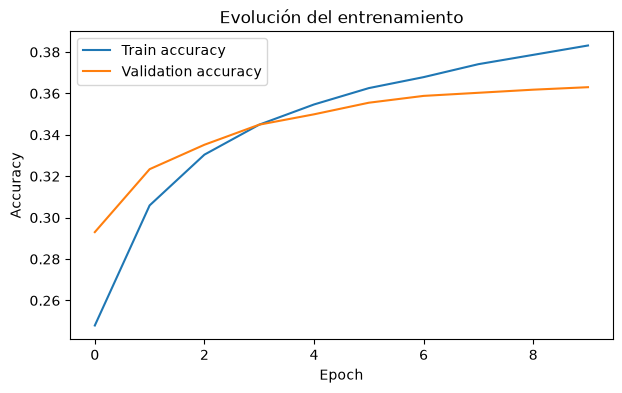

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()
plt.show()


### Pregunta 8

Observa las dos curvas. ¿Hay evidencia de overfitting? Justifica brevemente.

**Respuesta:** **No hay evidencia clara de overfitting.** En la epoch 10, el accuracy de entrenamiento es 0.383 y el de validación 0.363: una brecha de unos 2 puntos. Ambas curvas siguen subiendo y la `val_loss` bajó de 1.976 a 1.778 sin empezar a crecer. El problema es más bien de **subajuste**: la red fully-connected tiene poca capacidad para este problema y además solo se entrenó 10 epochs.



---
# 5. Evaluar el modelo

Completa `evaluate()`.


In [12]:
# TODO 5 — Evaluación
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")


Test loss     : 1.7775
Test accuracy : 0.3630
Accuracy (%)  : 36.30%


### Pregunta 9

Compara este resultado con Fashion-MNIST, utilizado en clase.

¿CIFAR-10 en escala de grises parece más fácil o más difícil para esta red? Justifica usando el accuracy obtenido.

**Respuesta:** **Más difícil.** Esta red obtuvo **36.30 %** en test. Para la misma arquitectura (784→128→10), el notebook de clase reporta como resultado esperado ~87–89 % en Fashion-MNIST (ese notebook no se re-ejecutó aquí). Aunque el azar es 10 % en ambos casos, CIFAR-10 son fotografías naturales con fondos, poses, escalas y posiciones variables, y al pasar a gris se pierde el color, que ayuda a distinguir clases (cielo/agua en airplane/ship, por ejemplo). En Fashion-MNIST las prendas están centradas, sobre fondo negro y alineadas.



---
# 6. Logits y Softmax

La salida de la red son 10 logits. Para interpretarlos como probabilidades necesitamos Softmax.


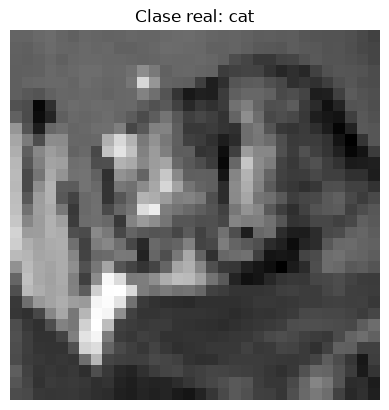

Logits:
[[ 0.91277087 -1.5765182   1.572216    0.31313083  1.0622674   0.2838921
   0.5608783   0.4730686  -0.2837162  -1.977528  ]]


In [13]:
index = 0
image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Clase real: {class_names[true_class]}")
plt.axis("off")
plt.show()

image_batch = np.expand_dims(image, axis=0)
logits = model(image_batch, training=False)

print("Logits:")
print(keras.ops.convert_to_numpy(logits))


In [14]:
# TODO 6 — Logits -> probabilidades
probabilities = keras.ops.softmax(logits)

# TODO 7 — Clase con mayor probabilidad
prediction = keras.ops.argmax(probabilities, axis=1)
prediction = int(keras.ops.convert_to_numpy(prediction)[0])

print("Clase real     :", class_names[true_class])
print("Clase predicha :", class_names[prediction])


Clase real     : cat
Clase predicha : bird


In [15]:
probabilities_np = keras.ops.convert_to_numpy(probabilities)[0]

print("\nProbabilidades:")
for i, p in enumerate(probabilities_np):
    marker = " ← predicción" if i == prediction else ""
    print(f"{class_names[i]:12s}: {p:.4f}{marker}")

print("\nSuma:", probabilities_np.sum())



Probabilidades:
airplane    : 0.1436
automobile  : 0.0119
bird        : 0.2776 ← predicción
cat         : 0.0788
deer        : 0.1667
dog         : 0.0765
frog        : 0.1010
horse       : 0.0925
ship        : 0.0434
truck       : 0.0080

Suma: 1.0000001


### Pregunta 10

¿Por qué las probabilidades producidas por `Softmax` deben sumar aproximadamente 1?

**Respuesta:** Porque Softmax normaliza: $p_k=e^{z_k}/\sum_j e^{z_j}$. Cada $p_k$ es positivo y el denominador es la suma de todos los numeradores, así que $\sum_k p_k=1$. Aquí la suma impresa es 1.0000001: la diferencia se debe al redondeo de punto flotante en `float32`.



---
# 7. Varias predicciones

Esta parte está resuelta. Observa especialmente los errores del modelo.


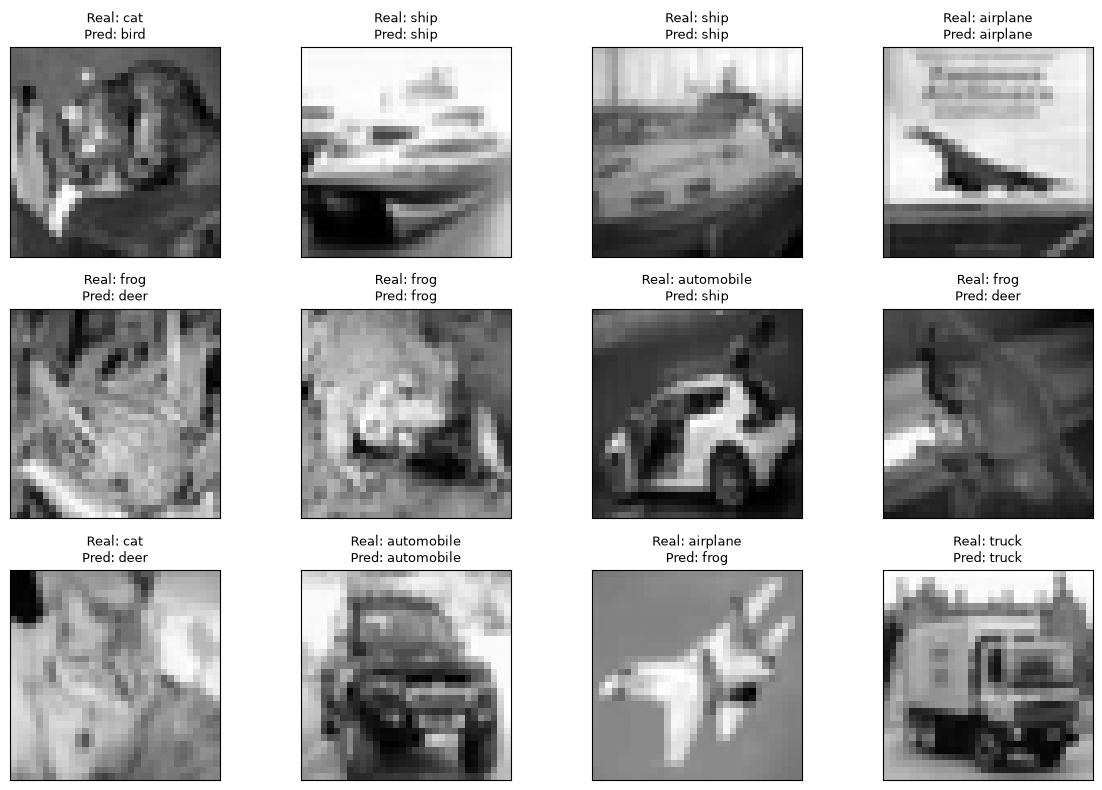

In [16]:
n = 12
logits_batch = model(X_test[:n], training=False)
predictions = keras.ops.argmax(logits_batch, axis=1)
predictions = keras.ops.convert_to_numpy(predictions)

plt.figure(figsize=(12, 8))
for i in range(n):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    real = class_names[y_test[i]]
    pred = class_names[predictions[i]]
    plt.title(f"Real: {real}\nPred: {pred}", fontsize=9)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


### Evidencia adicional (no pedida): accuracy por clase en test

Se calcula para responder con datos qué clases son más difíciles.

In [17]:
logits_test = model.predict(X_test, batch_size=256, verbose=0)
pred_test = np.argmax(logits_test, axis=1)

per_class = {name: float(np.mean(pred_test[y_test == k] == k)) for k, name in enumerate(class_names)}
for name, acc in sorted(per_class.items(), key=lambda t: t[1]):
    print(f"{name:12s}: {acc:.3f}")

print(f"\nAccuracy final train (última epoch): {history.history['accuracy'][-1]:.4f}")
print(f"Accuracy final validation/test      : {history.history['val_accuracy'][-1]:.4f}")

cat         : 0.192
dog         : 0.284
frog        : 0.303
bird        : 0.316
deer        : 0.346
truck       : 0.385
horse       : 0.388
automobile  : 0.407
airplane    : 0.433
ship        : 0.576

Accuracy final train (última epoch): 0.3831
Accuracy final validation/test      : 0.3630


---
# 8. Reflexión final

### 1. ¿Cuál fue el accuracy final?

**Respuesta:** **36.30 %** en test (loss 1.7775); en entrenamiento, 38.31 % en la última epoch.

### 2. ¿Qué clases parecen más difíciles de distinguir?

**Respuesta:** Según el accuracy por clase en test (celda de evidencia adicional), las más difíciles son los animales: **cat 19.2 %**, dog 28.4 %, frog 30.3 %, bird 31.6 % y deer 34.6 %. Son clases con formas y texturas parecidas entre sí. Las más fáciles son ship (57.6 %) y airplane (43.3 %), con fondos más característicos (agua y cielo). En el ejemplo mostrado, un gato fue clasificado como bird.

### 3. Después de `Flatten()`, la imagen se convierte en un vector de 1024 valores. ¿Qué información importante sobre la imagen podría perderse al tratarla únicamente como un vector?

**Respuesta:** Se pierde la **estructura espacial**: qué píxeles son vecinos, los patrones locales (bordes, texturas, partes del objeto) y su posición relativa. Para la red, el píxel 33 (fila 1, columna 1) y el píxel 34 son features independientes, y el mismo objeto desplazado unos píxeles produce un vector muy distinto, que la red debe aprender por separado.

### 4. ¿Qué tipo de arquitectura podría aprovechar mejor la estructura espacial de las imágenes?

**Respuesta:** Las **redes neuronales convolucionales (CNN)**: filtros locales con pesos compartidos que recorren la imagen, pooling y una jerarquía de características (bordes → formas → partes → objetos), con muchos menos parámetros por capa.

---

## Para pensar

Nuestro modelo hace:

```text
32×32 → Flatten → 1024 valores → Dense → ReLU → Dense(10)
```

Sin embargo, una imagen tiene **estructura espacial**: existen bordes, formas y patrones locales.

Este resultado nos deja preparada la siguiente pregunta del curso:

> **¿Cómo puede una red aprovechar directamente la estructura espacial de una imagen?**

La respuesta será: **Convolutional Neural Networks (CNNs)**.
